<a href="https://colab.research.google.com/github/vyshnavivallepu7-code/Machine-learning/blob/main/ml_online_exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 records:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Dataset Shape:
(541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing Values:
InvoiceNo           0
StockCo

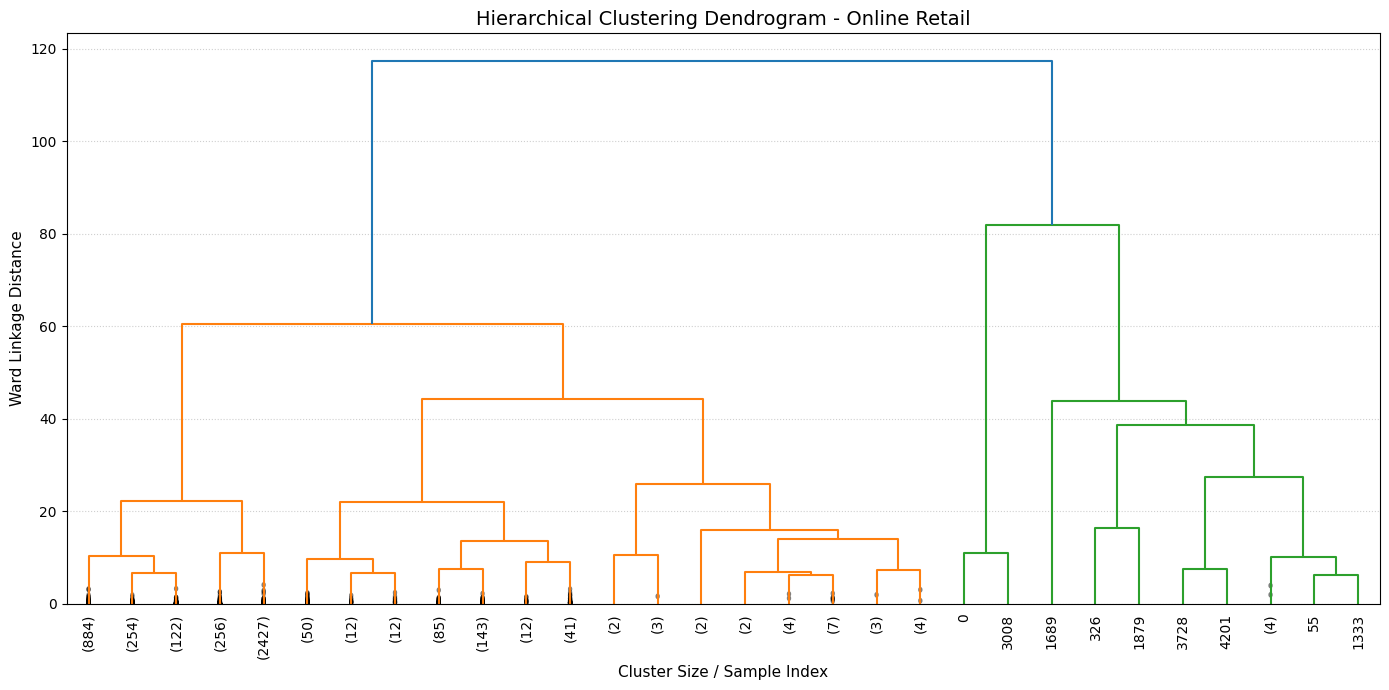


Number of clusters selected: 3

Customer Cluster Assignments:
    CustomerID  TotalSpent  TotalQuantity  NumInvoices  AverageOrderValue  \
0      12346.0    77183.60          74215            1       77183.600000   
1      12347.0     4310.00           2458            7         615.714286   
2      12348.0     1797.24           2341            4         449.310000   
3      12349.0     1757.55            631            1        1757.550000   
4      12350.0      334.40            197            1         334.400000   
5      12352.0     2506.04            536            8         313.255000   
6      12353.0       89.00             20            1          89.000000   
7      12354.0     1079.40            530            1        1079.400000   
8      12355.0      459.40            240            1         459.400000   
9      12356.0     2811.43           1591            3         937.143333   
10     12357.0     6207.67           2708            1        6207.670000   
11     12358.

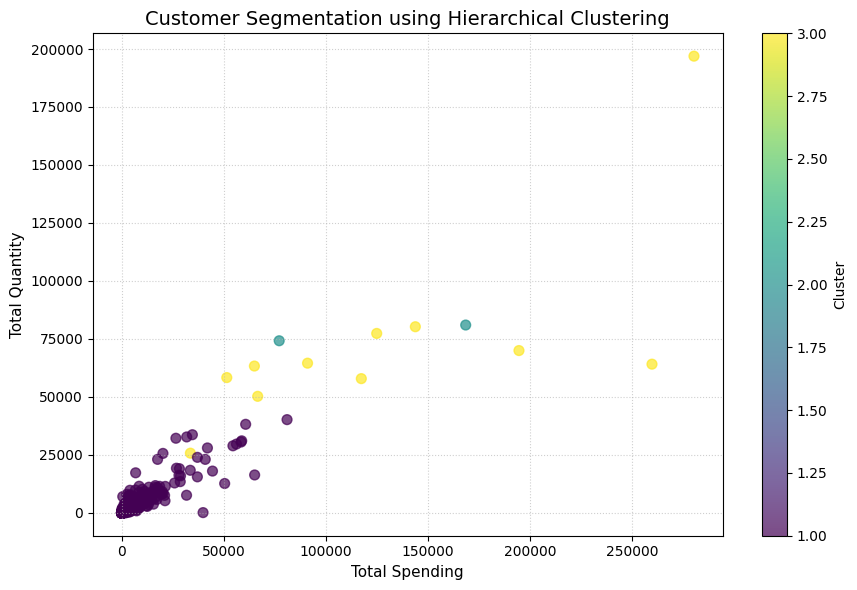

In [ ]:
# ============================================================
# HIERARCHICAL AGGLOMERATIVE CLUSTERING
# Online Retail Dataset
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------

df = pd.read_csv(
    "/content/OnlineRetail.csv",
    encoding="latin1"
)

print("First 5 records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. Check missing values
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 3. Remove rows with missing CustomerID
# ------------------------------------------------------------

df = df.dropna(subset=['CustomerID'])

print("\nShape after removing missing CustomerID:")
print(df.shape)


# ------------------------------------------------------------
# 4. Remove cancelled transactions
# ------------------------------------------------------------

# Invoice numbers starting with 'C' represent cancellations
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


# ------------------------------------------------------------
# 5. Remove invalid Quantity and UnitPrice values
# ------------------------------------------------------------

df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
]


# ------------------------------------------------------------
# 6. Create Total Spending
# ------------------------------------------------------------

df['TotalSpent'] = df['Quantity'] * df['UnitPrice']

print("\nData after preprocessing:")
print(df.head())


# ------------------------------------------------------------
# 7. Create customer-level features
# ------------------------------------------------------------

customer_data = df.groupby('CustomerID').agg({

    'TotalSpent': 'sum',

    'Quantity': 'sum',

    'InvoiceNo': 'nunique'

}).reset_index()


# Rename columns

customer_data = customer_data.rename(
    columns={
        'Quantity': 'TotalQuantity',
        'InvoiceNo': 'NumInvoices'
    }
)


# ------------------------------------------------------------
# 8. Calculate Average Order Value
# ------------------------------------------------------------

customer_data['AverageOrderValue'] = (
    customer_data['TotalSpent'] /
    customer_data['NumInvoices']
)


print("\nCustomer-level data:")
print(customer_data.head())


print("\nCustomer Dataset Shape:")
print(customer_data.shape)


# ------------------------------------------------------------
# 9. Select features for clustering
# ------------------------------------------------------------

features = [
    'TotalSpent',
    'TotalQuantity',
    'NumInvoices',
    'AverageOrderValue'
]

X = customer_data[features]

print("\nFeatures selected for clustering:")
print(X.head())


# ------------------------------------------------------------
# 10. Standardize the features
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized Data:")
print(X_scaled[:5])


# ------------------------------------------------------------
# 11. Compute Hierarchical Linkage
# ------------------------------------------------------------

mergings = linkage(
    X_scaled,
    method='ward',
    metric='euclidean'
)


# ------------------------------------------------------------
# 12. Plot Dendrogram
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

dendrogram(
    mergings,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title(
    'Hierarchical Clustering Dendrogram - Online Retail',
    fontsize=14
)

plt.xlabel(
    'Cluster Size / Sample Index',
    fontsize=11
)

plt.ylabel(
    'Ward Linkage Distance',
    fontsize=11
)

plt.grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Select number of clusters
# ------------------------------------------------------------

optimal_k = 3

print("\nNumber of clusters selected:", optimal_k)


# ------------------------------------------------------------
# 14. Create clusters
# ------------------------------------------------------------

cluster_labels = fcluster(
    mergings,
    t=optimal_k,
    criterion='maxclust'
)

customer_data['Cluster'] = cluster_labels


# ------------------------------------------------------------
# 15. Display customer cluster assignments
# ------------------------------------------------------------

print("\nCustomer Cluster Assignments:")

print(
    customer_data[
        [
            'CustomerID',
            'TotalSpent',
            'TotalQuantity',
            'NumInvoices',
            'AverageOrderValue',
            'Cluster'
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 16. Cluster Profile
# ------------------------------------------------------------

cluster_profile = customer_data.groupby('Cluster').agg({

    'TotalSpent': 'mean',

    'TotalQuantity': 'mean',

    'NumInvoices': 'mean',

    'AverageOrderValue': 'mean',

    'CustomerID': 'count'

}).round(2)


# Rename CustomerID column

cluster_profile = cluster_profile.rename(
    columns={
        'CustomerID': 'Number of Customers'
    }
)


print("\n================ CLUSTER PROFILE ================")

print(cluster_profile)


# ------------------------------------------------------------
# 17. Number of customers in each cluster
# ------------------------------------------------------------

print("\nNumber of customers in each cluster:")

print(
    customer_data['Cluster']
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 18. Visualize clusters
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    customer_data['TotalSpent'],
    customer_data['TotalQuantity'],
    c=customer_data['Cluster'],
    s=50,
    alpha=0.7
)

plt.title(
    'Customer Segmentation using Hierarchical Clustering',
    fontsize=14
)

plt.xlabel(
    'Total Spending',
    fontsize=11
)

plt.ylabel(
    'Total Quantity',
    fontsize=11
)

plt.colorbar(
    scatter,
    label='Cluster'
)

plt.grid(
    linestyle=':',
    alpha=0.6
)

plt.tight_layout()
plt.show()